In [10]:
import pandas as pd

# DataFrame 中的浮点数统一显示两位小数
pd.options.display.float_format = "{:.2f}".format

df = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
0,1,0,3,male,22.00,7.25,S
1,2,1,1,female,38.00,71.28,C
2,3,1,3,female,26.00,7.92,S
3,4,1,1,female,35.00,53.10,S
4,5,0,3,male,35.00,8.05,S
5,6,0,3,male,NaN,8.46,Q
6,7,0,1,male,54.00,51.86,S
7,8,0,3,male,2.00,21.08,S
8,9,1,3,female,27.00,11.13,S
9,10,1,2,female,14.00,30.07,C


In [11]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
0,1,0,3,male,22.00,7.25,S
1,2,1,1,female,38.00,71.28,C
2,3,1,3,female,26.00,7.92,S
3,4,1,1,female,35.00,53.10,S
4,5,0,3,male,35.00,8.05,S


In [12]:
df.shape

(20, 7)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  20 non-null     int64  
 1   Survived     20 non-null     int64  
 2   Pclass       20 non-null     int64  
 3   Sex          20 non-null     str    
 4   Age          18 non-null     float64
 5   Fare         20 non-null     float64
 6   Embarked     20 non-null     str    
dtypes: float64(2), int64(3), str(2)
memory usage: 1.2 KB


In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            2
Fare           0
Embarked       0
dtype: int64

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
Embarked       0
dtype: int64

In [16]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
0,1,0,3,0,22.00,7.25,0
1,2,1,1,1,38.00,71.28,1
2,3,1,3,1,26.00,7.92,0
3,4,1,1,1,35.00,53.10,0
4,5,0,3,0,35.00,8.05,0


In [17]:
X = df[["Pclass", "Sex", "Age", "Fare", "Embarked"]]
y = df["Survived"]

print(X.head())
print(y.head())

   Pclass  Sex   Age  Fare  Embarked
0       3    0 22.00  7.25         0
1       1    1 38.00 71.28         1
2       3    1 26.00  7.92         0
3       1    1 35.00 53.10         0
4       3    0 35.00  8.05         0
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("训练集数量：", len(X_train))
print("测试集数量：", len(X_test))

训练集数量： 14
测试集数量： 6


In [19]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report

lr_accuracy = float(accuracy_score(y_test, lr_pred))
dt_accuracy = float(accuracy_score(y_test, dt_pred))
rf_accuracy = float(accuracy_score(y_test, rf_pred))

print(f"逻辑回归准确率：{lr_accuracy:.2f}")
print(f"决策树准确率：{dt_accuracy:.2f}")
print(f"随机森林准确率：{rf_accuracy:.2f}")

逻辑回归准确率：0.67
决策树准确率：0.67
随机森林准确率：0.83


In [23]:
print(classification_report(y_test, rf_pred, digits=2))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



In [24]:
feature_names_cn = {
    "Pclass": "客舱等级",
    "Sex": "性别",
    "Age": "年龄",
    "Fare": "票价",
    "Embarked": "登船港口"
}

feature_importance = pd.DataFrame({
    "特征": [feature_names_cn[name] for name in X.columns],
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance["importance"] = feature_importance["importance"].round(2)
feature_importance = feature_importance.rename(columns={"importance": "重要性"})

feature_importance

,特征,重要性
1,性别,0.34
3,票价,0.24
2,年龄,0.20
4,登船港口,0.11
0,客舱等级,0.11


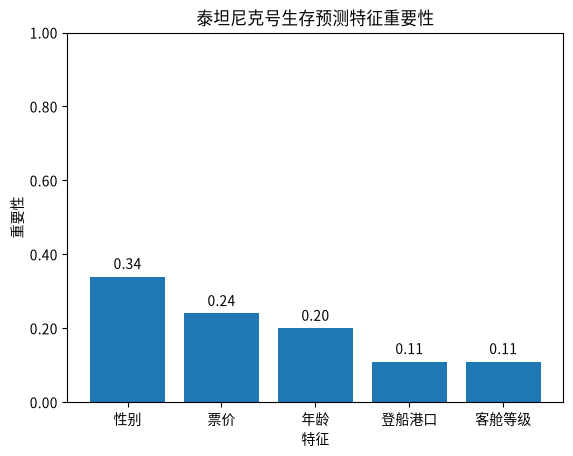

In [25]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import FormatStrFormatter

# 直接加载中文字体，避免图表中的汉字显示为方框
font_path = "/home/penglei/.local/share/fonts/NotoSansCJKsc-Regular.otf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

plt.bar(feature_importance["特征"], feature_importance["重要性"])
plt.xlabel("特征")
plt.ylabel("重要性")
plt.title("泰坦尼克号生存预测特征重要性")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

for index, value in enumerate(feature_importance["重要性"]):
    plt.text(index, value + 0.02, f"{float(value):.2f}", ha="center")

plt.show()

In [1]:
import torch

x = torch.rand(5, 3)
print(x)
print(torch.__version__)

tensor([[0.6236, 0.0147, 0.5834],
        [0.0055, 0.0598, 0.7425],
        [0.1384, 0.7261, 0.6450],
        [0.5012, 0.1332, 0.8789],
        [0.3743, 0.2326, 0.9331]])
2.12.1+cu130
